In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [2]:
def find_project_root() -> Path:
    """Find the project directory containing the src folder."""
    current_directory = Path.cwd().resolve()

    candidates = [
        current_directory,
        current_directory.parent,
    ]

    for candidate in candidates:
        if (candidate / "src").is_dir():
            return candidate

    raise RuntimeError(
        "Could not find the project root containing src/."
    )


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: D:\astar-costmap-project


In [3]:
from src.scene_generator import (
    DrivingScene,
    generate_driving_scene,
    make_gaussian_point_map,
)

from src.planners import (
    AStarResult,
    astar_search,
    calculate_path_length,
    path_exists,
    validate_path,
)

# Synthetic Driving Scene Generation

This notebook generates simplified bird's-eye-view grid maps for the
CNN-guided A* path-planning project.

Each scene contains:

1. Drivable-area mask
2. Obstacle mask
3. Lane-center preference map
4. Start-point map
5. Goal-point map

In [4]:
from dataclasses import dataclass
from collections import deque
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

## 1. Scene Data Structure

Each synthetic scene stores five input channels together with the
start and goal coordinates.

Shape: (64, 64)
Maximum value: 1.0
Maximum position: (np.int64(50), np.int64(32))


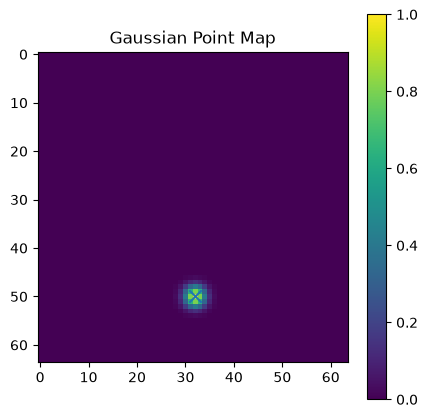

In [5]:
test_map = make_gaussian_point_map(
    height=64,
    width=64,
    point=(50, 32),
    sigma=1.5,
)

print("Shape:", test_map.shape)
print("Maximum value:", test_map.max())
print("Maximum position:", np.unravel_index(
    np.argmax(test_map),
    test_map.shape,
))

plt.figure(figsize=(5, 5))
plt.imshow(test_map)
plt.title("Gaussian Point Map")
plt.scatter(32, 50, marker="x", s=80)
plt.colorbar()
plt.show()

## 2. Path-Existence Check

A breadth-first search is used to verify that each randomly generated
scene contains at least one collision-free path from the start to the goal.

In [6]:
# Create a small test map.
test_free_space = np.ones(
    (10, 10),
    dtype=bool,
)

test_start = (8, 2)
test_goal = (1, 7)

print(
    "Open map:",
    path_exists(
        test_free_space,
        test_start,
        test_goal,
    ),
)

# Add a complete horizontal wall.
blocked_free_space = test_free_space.copy()
blocked_free_space[5, :] = False

print(
    "Blocked map:",
    path_exists(
        blocked_free_space,
        test_start,
        test_goal,
    ),
)

Open map: True
Blocked map: False


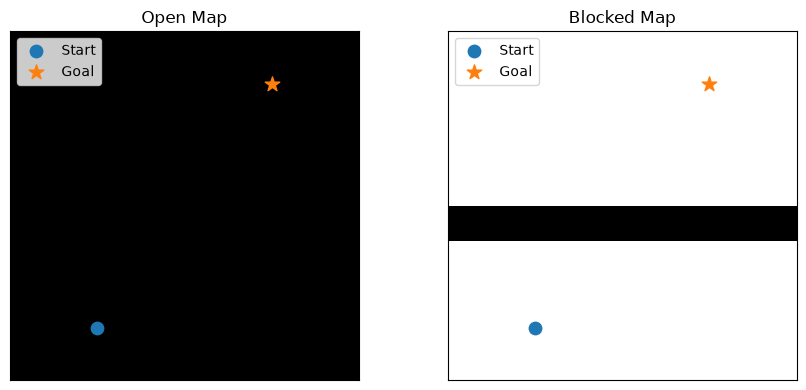

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(9, 4),
)

test_cases = [
    ("Open Map", test_free_space),
    ("Blocked Map", blocked_free_space),
]

for axis, (title, free_space) in zip(
    axes,
    test_cases,
):
    axis.imshow(
        free_space,
        cmap="gray",
        origin="upper",
    )

    axis.scatter(
        test_start[1],
        test_start[0],
        marker="o",
        s=80,
        label="Start",
    )

    axis.scatter(
        test_goal[1],
        test_goal[0],
        marker="*",
        s=120,
        label="Goal",
    )

    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend()

plt.tight_layout()
plt.show()

## 3. Synthetic Driving Scene Generation

The reusable implementation is provided in `src/scene_generator.py`.
This section tests and visualizes the procedural scene generator.

In [8]:
scene = generate_driving_scene(
    seed=4,
)

print(
    "Road mask shape:",
    scene.road_mask.shape,
)

print(
    "Obstacle mask shape:",
    scene.obstacle_mask.shape,
)

print(
    "Model input shape:",
    scene.model_input.shape,
)

print(
    "Start:",
    scene.start,
)

print(
    "Goal:",
    scene.goal,
)

print(
    "Number of obstacle cells:",
    scene.obstacle_mask.sum(),
)

print(
    "Valid path exists:",
    path_exists(
        free_space=scene.free_space,
        start=scene.start,
        goal=scene.goal,
    ),
)

Road mask shape: (64, 64)
Obstacle mask shape: (64, 64)
Model input shape: (5, 64, 64)
Start: (61, 32)
Goal: (2, 31)
Number of obstacle cells: 120
Valid path exists: True


## 4. Scene Visualization

The five channels are visualized separately, together with a combined
bird's-eye-view representation of the scene.

In [9]:
def plot_scene_channels(
    scene: DrivingScene,
) -> None:
    """
    Visualize the five CNN input channels and the combined scene.
    """
    channel_names = [
        "Drivable Area",
        "Obstacle Mask",
        "Lane-Center Preference",
        "Start Map",
        "Goal Map",
    ]

    channels = scene.model_input

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(13, 8),
    )

    axes = axes.ravel()

    # Plot the five separate channels.
    for index in range(5):
        image = axes[index].imshow(
            channels[index],
            origin="upper",
        )

        axes[index].set_title(
            channel_names[index]
        )

        axes[index].set_xticks([])
        axes[index].set_yticks([])

        fig.colorbar(
            image,
            ax=axes[index],
            fraction=0.046,
            pad=0.04,
        )

    # Plot the combined scene.
    axes[5].imshow(
        scene.road_mask,
        cmap="gray",
        origin="upper",
    )

    obstacle_overlay = np.ma.masked_where(
        ~scene.obstacle_mask,
        scene.obstacle_mask,
    )

    axes[5].imshow(
        obstacle_overlay,
        cmap="Reds",
        alpha=0.9,
        origin="upper",
    )

    axes[5].plot(
        scene.centerline_x,
        np.arange(
            scene.road_mask.shape[0]
        ),
        linestyle="--",
        linewidth=1.5,
        label="Lane center",
    )

    axes[5].scatter(
        scene.start[1],
        scene.start[0],
        marker="o",
        s=80,
        label="Start",
    )

    axes[5].scatter(
        scene.goal[1],
        scene.goal[0],
        marker="*",
        s=130,
        label="Goal",
    )

    axes[5].set_title(
        "Combined Scene"
    )

    axes[5].set_xlim(
        0,
        scene.road_mask.shape[1] - 1,
    )

    axes[5].set_ylim(
        scene.road_mask.shape[0] - 1,
        0,
    )

    axes[5].set_aspect("equal")

    axes[5].legend(
        loc="upper right"
    )

    plt.tight_layout()
    plt.show()

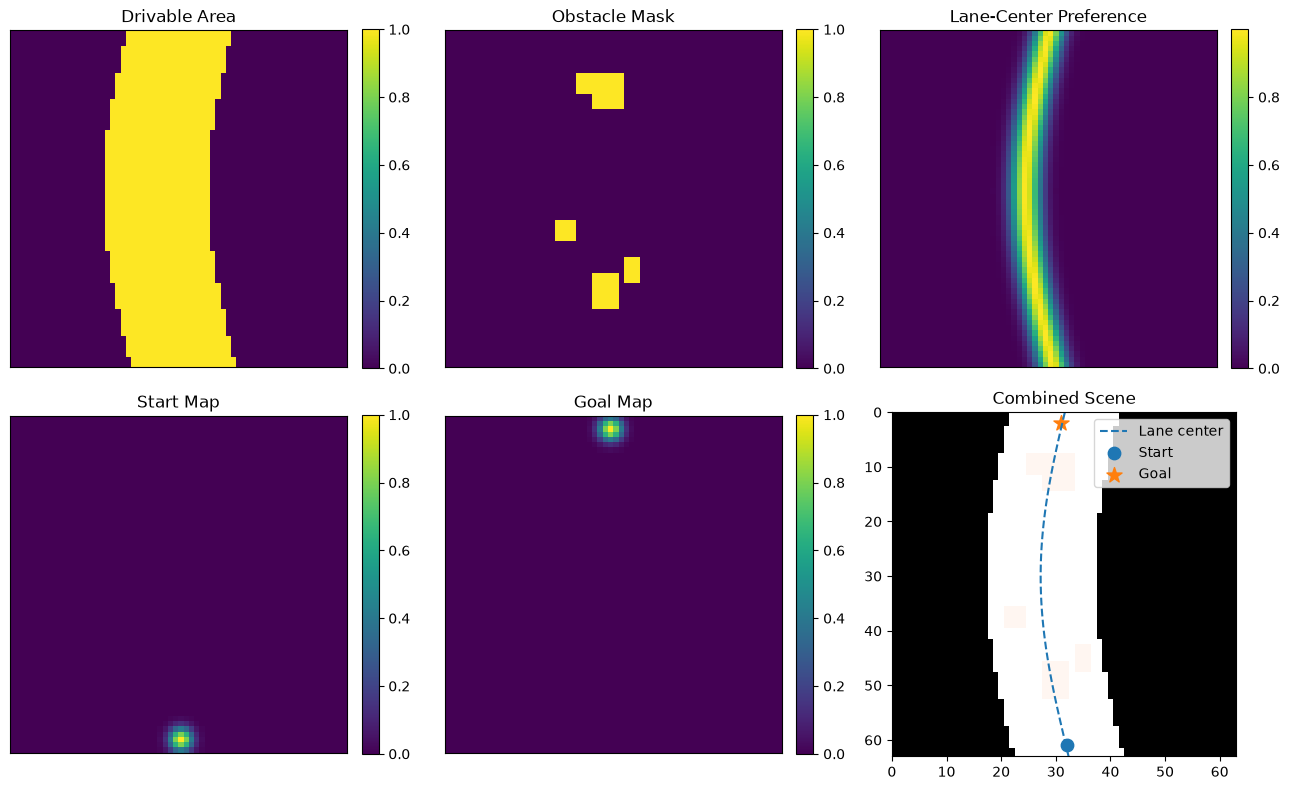

In [10]:
plot_scene_channels(scene)

## 5. Multiple-Scene Inspection

Several scenes are generated with different random seeds to inspect
the diversity and validity of the procedural map generator.

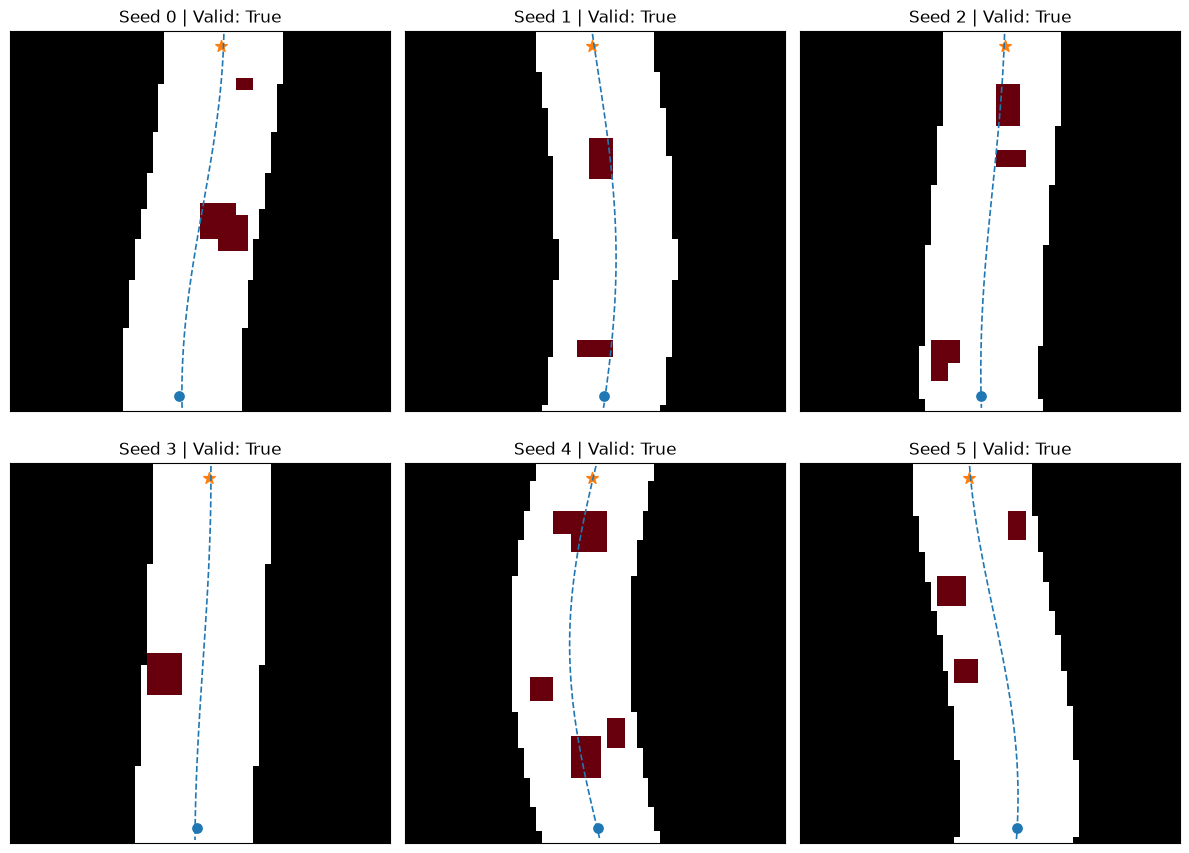

In [11]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 9),
)

axes = axes.ravel()

for index, seed in enumerate(range(6)):
    sample_scene = generate_driving_scene(seed=seed)

    # Outside the road is dark; drivable road is light.
    axes[index].imshow(
        sample_scene.road_mask,
        cmap="gray",
        origin="upper",
    )

    # Show obstacles clearly.
    obstacle_overlay = np.ma.masked_where(
        ~sample_scene.obstacle_mask,
        sample_scene.obstacle_mask,
    )

    axes[index].imshow(
        obstacle_overlay,
        cmap="Reds",
        vmin=0,
        vmax=1,
        alpha=1.0,
        origin="upper",
    )

    # Road centerline.
    axes[index].plot(
        sample_scene.centerline_x,
        np.arange(sample_scene.road_mask.shape[0]),
        linestyle="--",
        linewidth=1.2,
        label="Lane center",
    )

    # Start and goal.
    axes[index].scatter(
        sample_scene.start[1],
        sample_scene.start[0],
        marker="o",
        s=45,
        label="Start",
    )

    axes[index].scatter(
        sample_scene.goal[1],
        sample_scene.goal[0],
        marker="*",
        s=75,
        label="Goal",
    )

    valid = path_exists(
        sample_scene.free_space,
        sample_scene.start,
        sample_scene.goal,
    )

    axes[index].set_title(
        f"Seed {seed} | Valid: {valid}"
    )

    axes[index].set_xticks([])
    axes[index].set_yticks([])
    axes[index].set_aspect("equal")

plt.tight_layout()
plt.show()

In [12]:
number_of_test_scenes = 100
valid_scene_count = 0

for seed in range(number_of_test_scenes):
    test_scene = generate_driving_scene(seed=seed)

    valid = path_exists(
        test_scene.free_space,
        test_scene.start,
        test_scene.goal,
    )

    if valid:
        valid_scene_count += 1

print(
    f"Valid scenes: "
    f"{valid_scene_count}/{number_of_test_scenes}"
)

Valid scenes: 100/100


## 6. Standard A* Path Planning

The reusable A* implementation is provided in `src/planners.py`.
This section validates the planner on the generated scenes.

In [13]:
import heapq
import time
from dataclasses import dataclass

In [14]:
astar_result = astar_search(
    free_space=scene.free_space,
    start=scene.start,
    goal=scene.goal,
)

print("Success:", astar_result.success)
print("Path length:", astar_result.path_length)
print("Expanded nodes:", astar_result.expanded_nodes)
print(
    "Planning time:",
    f"{astar_result.planning_time * 1000:.3f} ms",
)
print("Number of path cells:", len(astar_result.path))

Success: True
Path length: 61.07106781186546
Expanded nodes: 164
Planning time: 0.693 ms
Number of path cells: 60


## 7. Standard A* Path Visualization

The standard A* path is overlaid on the generated driving scene to
verify collision avoidance and path connectivity.

In [15]:
def plot_astar_path(
    scene: DrivingScene,
    result: AStarResult,
    title: str = "Standard A* Path",
) -> None:
    """
    Plot an A* result on top of a driving scene.
    """
    fig, ax = plt.subplots(
        figsize=(7, 7),
    )

    # Road area.
    ax.imshow(
        scene.road_mask,
        cmap="gray",
        origin="upper",
    )

    # Obstacles.
    obstacle_overlay = np.ma.masked_where(
        ~scene.obstacle_mask,
        scene.obstacle_mask,
    )

    ax.imshow(
        obstacle_overlay,
        cmap="Reds",
        vmin=0,
        vmax=1,
        alpha=1.0,
        origin="upper",
    )

    # Lane centerline.
    ax.plot(
        scene.centerline_x,
        np.arange(scene.road_mask.shape[0]),
        linestyle="--",
        linewidth=1.5,
        label="Lane center",
    )

    # Planned path.
    if result.success and result.path:
        path_array = np.asarray(result.path)

        path_rows = path_array[:, 0]
        path_cols = path_array[:, 1]

        ax.plot(
            path_cols,
            path_rows,
            linewidth=2.5,
            label="Standard A* path",
        )

    # Start and goal.
    ax.scatter(
        scene.start[1],
        scene.start[0],
        marker="o",
        s=100,
        edgecolors="black",
        label="Start",
        zorder=5,
    )

    ax.scatter(
        scene.goal[1],
        scene.goal[0],
        marker="*",
        s=180,
        edgecolors="black",
        label="Goal",
        zorder=5,
    )

    status_text = (
        f"Success: {result.success}\n"
        f"Length: {result.path_length:.2f}\n"
        f"Expanded nodes: {result.expanded_nodes}\n"
        f"Planning time: {result.planning_time * 1000:.3f} ms"
    )

    ax.text(
        0.02,
        0.02,
        status_text,
        transform=ax.transAxes,
        verticalalignment="bottom",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85,
        },
    )

    ax.set_title(title)
    ax.set_xlim(0, scene.road_mask.shape[1] - 1)
    ax.set_ylim(scene.road_mask.shape[0] - 1, 0)
    ax.set_aspect("equal")
    ax.set_xlabel("Grid column")
    ax.set_ylabel("Grid row")
    ax.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

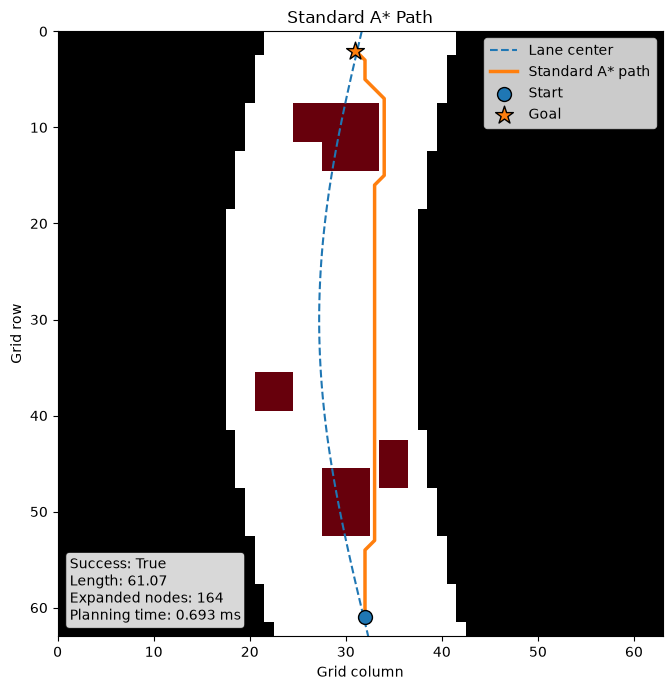

In [16]:
plot_astar_path(
    scene=scene,
    result=astar_result,
)

In [17]:
path_is_valid = validate_path(
    free_space=scene.free_space,
    path=astar_result.path,
    start=scene.start,
    goal=scene.goal,
)

print("Path is valid:", path_is_valid)

Path is valid: True
